In [7]:
# House Price Prediction with Heterogeneous Neighborhoods
# Name: Mera Makar

In [21]:
def generate_houses(n_total=2000, rich_fraction=0.4, seed=RNG_SEED):
    rng = np.random.default_rng(seed)

    n_rich = int(round(n_total * rich_fraction))
    n_poor = n_total - n_rich

    rich_x = rng.normal(loc=75, scale=6, size=n_rich)
    rich_y = rng.normal(loc=75, scale=6, size=n_rich)

    poor_x = rng.normal(loc=25, scale=8, size=n_poor)
    poor_y = rng.normal(loc=25, scale=8, size=n_poor)

    rich_sqft = rng.uniform(1800, 4500, size=n_rich)
    poor_sqft = rng.uniform(800, 2000, size=n_poor)

    rich = pd.DataFrame({
        "x": rich_x,
        "y": rich_y,
        "sqft": rich_sqft,
        "neighborhood": "rich",
    })

    poor = pd.DataFrame({
        "x": poor_x,
        "y": poor_y,
        "sqft": poor_sqft,
        "neighborhood": "poor",
    })

    df = pd.concat([rich, poor], ignore_index=True)

    df["num_bedrooms"] = np.clip(
        np.round(df["sqft"] / 600 + rng.normal(0, 0.3, len(df))),
        1,
        6
    ).astype(int)

    df["num_bathrooms"] = np.clip(
        np.round(df["num_bedrooms"] / 1.5 + rng.normal(0, 0.4, len(df))),
        1,
        5
    ).astype(int)

    price_rich = (
        50000
        + 350 * df["sqft"]
        + 20000 * df["num_bedrooms"]
        + 15000 * df["num_bathrooms"]
        + rng.normal(0, 30000, len(df))
    )

    price_poor = (
        30000
        + 120 * df["sqft"]
        + 10000 * df["num_bedrooms"]
        + 8000 * df["num_bathrooms"]
        + rng.normal(0, 20000, len(df))
    )

    df["price"] = np.where(
        df["neighborhood"] == "rich",
        price_rich,
        price_poor
    )

    df = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    return df

In [22]:
houses = generate_houses()
print(houses.head())
print(f"\nshape: {houses.shape}")
print(houses["neighborhood"].value_counts())

           x          y         sqft neighborhood  num_bedrooms  \
0  16.933529  15.282653  1316.271832         poor             2   
1  79.882582  71.631102  3121.269831         rich             5   
2  27.592714  21.820133  1780.867445         poor             2   
3  40.223260  25.329440  1538.276061         poor             2   
4  28.742558  16.771966  1026.734901         poor             2   

   num_bathrooms         price  
0              1  2.101732e+05  
1              3  1.276709e+06  
2              2  2.779173e+05  
3              1  2.570214e+05  
4              1  1.742794e+05  

shape: (2000, 7)
neighborhood
poor    1200
rich     800
Name: count, dtype: int64


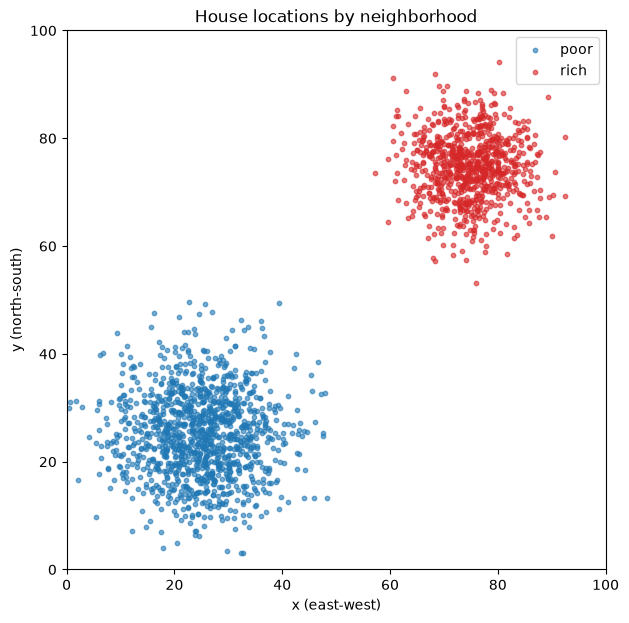

In [24]:
fig, ax = plt.subplots(figsize=(7, 7))

for color, label in [("tab:blue", "poor"), ("tab:red", "rich")]:
    subset = houses[houses["neighborhood"] == label]
    ax.scatter(
        subset["x"],
        subset["y"],
        s=10,
        alpha=0.6,
        label=label,
        color=color
    )

ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_aspect("equal")
ax.set_xlabel("x (east-west)")
ax.set_ylabel("y (north-south)")
ax.set_title("House locations by neighborhood")
ax.legend()

plt.show()

In [25]:
FEATURES = ["x", "y", "sqft", "num_bedrooms", "num_bathrooms"]

X = houses[FEATURES].to_numpy()
y = houses["price"].to_numpy()
neigh = houses["neighborhood"].to_numpy()

X_train, X_test, y_train, y_test, neigh_train, neigh_test = train_test_split(
    X, y, neigh, test_size=0.25, random_state=RNG_SEED
)

global_model = LinearRegression()
global_model.fit(X_train, y_train)

y_pred = global_model.predict(X_test)

global_mse = mean_squared_error(y_test, y_pred)
global_rmse = np.sqrt(global_mse)

print(f"Global model MSE  (test): {global_mse:>18,.0f}  (dollars-squared)")
print(f"Global model RMSE (test): ${global_rmse:>15,.0f}  (dollars; sqrt of MSE)")

print()

print("Per-neighborhood test RMSE under the global model:")

for label in ["rich", "poor"]:
    mask = neigh_test == label
    rmse_label = np.sqrt(mean_squared_error(y_test[mask], y_pred[mask]))
    print(f"  {label:>4}: ${rmse_label:>10,.0f}  (n={mask.sum()})")

Global model MSE  (test):      5,888,022,312  (dollars-squared)
Global model RMSE (test): $         76,733  (dollars; sqrt of MSE)

Per-neighborhood test RMSE under the global model:
  rich: $    61,506  (n=201)
  poor: $    85,458  (n=299)


In [31]:
per_neighborhood_models = {}
per_neighborhood_metrics = {}

for label in ["rich", "poor"]:
    train_mask = neigh_train == label
    test_mask = neigh_test == label

    model = LinearRegression()
    model.fit(X_train[train_mask], y_train[train_mask])

    y_pred_label = model.predict(X_test[test_mask])

    mse = mean_squared_error(y_test[test_mask], y_pred_label)
    rmse = np.sqrt(mse)

    per_neighborhood_models[label] = model
    per_neighborhood_metrics[label] = {
        "mse": mse,
        "rmse": rmse,
        "n_test": int(test_mask.sum())
    }

    print(f"{label:>4} model RMSE (test): ${rmse:>10,.0f}   (n={test_mask.sum()})")


y_pred_per = np.empty_like(y_test, dtype=float)

for label, model in per_neighborhood_models.items():
    mask = neigh_test == label
    y_pred_per[mask] = model.predict(X_test[mask])


combined_mse = mean_squared_error(y_test, y_pred_per)
combined_rmse = np.sqrt(combined_mse)

print(f"\nCombined per-neighborhood MSE  (test): {combined_mse:>18,.0f}")
print(f"Combined per-neighborhood RMSE (test): ${combined_rmse:>15,.0f}")
print("Rich-only MSE:", per_neighborhood_metrics["rich"]["mse"])
print("Poor-only MSE:", per_neighborhood_metrics["poor"]["mse"])

rich model RMSE (test): $    30,671   (n=201)
poor model RMSE (test): $    21,398   (n=299)

Combined per-neighborhood MSE  (test):        651,964,103
Combined per-neighborhood RMSE (test): $         25,534
Rich-only MSE: 940706375.1289402
Poor-only MSE: 457859766.14724785


In [33]:
# Task 6: Questions and answers: 
# Model                                          Test MSE         Test RMSE ($)
#One global linear regression                  5,888,022,312        76,733
# Two per-neighborhood regressions (combined)  651,964,103          25,534
# Rich-only model on rich test rows             940,706,375          30,671
# Poor-only model on poor test rows             457,859,766          21,398
# Questions: 
# 1. Which approach has the lower overall test MSE?: The two per neighborhood models have the lower MSE because they each learn from one neighborhood instead of trying to fit both neighborhoods with one model.
# 2. Look at the per-neighborhood RMSE under the global model (printed at the end of Task 4). Is it the same for rich and poor, or does the global model systematically perform worse on one of the two neighborhoods? Why?: No, it is different. The global model does worse on the poor neighborhood because rich and poor houses have different price patterns, so one model cannot fit both perfectly.
# 3. The two-models approach trains each model on roughly half the data of the global model. Why does it still win? What is each smaller model getting in exchange for the smaller training set?: Each model gets to focus on one neighborhood and learn its own pattern. It has less data, but it gets better information about that specific group.
# 4. Prediction for Task 7. In the next task you will add a one-hot encoded neighborhood feature to the global model. Before you run it, predict: will adding that single binary feature close the gap with the two-models approach completely, partially, or not at all? 
#Justify your prediction in terms of what an extra one-hot feature lets a linear model express.: It will close the gap partially. It can tell the model if a house is rich or poor, but it cannot make the model use different slopes for each neighborhood.
# 5. If, instead of two cleanly separated neighborhoods, the dataset had a smooth gradient (e.g., price-per-sqft varied continuously across the 
# plane), would the two-models approach still help? What would you change?: Probably not as much. I would use location features like x and y to help the model learn the changes. 




In [34]:
is_rich = (neigh == "rich").astype(int).reshape(-1, 1)
X_aug = np.hstack([X, is_rich])

X_aug_train, X_aug_test, _, _, _, _ = train_test_split(
    X_aug, y, neigh, test_size=0.25, random_state=RNG_SEED
)

onehot_model = LinearRegression()
onehot_model.fit(X_aug_train, y_train)

y_pred_onehot = onehot_model.predict(X_aug_test)
onehot_mse = mean_squared_error(y_test, y_pred_onehot)
onehot_rmse = np.sqrt(onehot_mse)

print(f"Global + one-hot model MSE  (test): {onehot_mse:>18,.0f}")
print(f"Global + one-hot model RMSE (test): ${onehot_rmse:>15,.0f}")
print()
print("Per-neighborhood test RMSE under the global + one-hot model:")
for label in ["rich", "poor"]:
    mask = neigh_test == label
    rmse_label = np.sqrt(mean_squared_error(y_test[mask], y_pred_onehot[mask]))
    print(f"  {label:>4}: ${rmse_label:>10,.0f}  (n={mask.sum()})")

print()
print("Coefficient on the new is_rich feature (intercept shift, in dollars):")
print(f"  w_is_rich = ${onehot_model.coef_[-1]:,.0f}")

Global + one-hot model MSE  (test):      4,177,027,926
Global + one-hot model RMSE (test): $         64,630

Per-neighborhood test RMSE under the global + one-hot model:
  rich: $    60,278  (n=201)
  poor: $    67,397  (n=299)

Coefficient on the new is_rich feature (intercept shift, in dollars):
  w_is_rich = $480,643


In [35]:
# Task 7: Questions and answers: 
# Model                                          Test MSE        Test RMSE ($) 
#  Bare global linear regression (Task 4)       5,888,022,312       76,733 
# Global + one-hot is_rich (Task 7)             4,177,027,926       64,630 
# Two per-neighborhood regressions (Task 5)     651,964,103         25,534 

# 1. Did the one-hot fully close the gap with the two-models approach, or only partially? By how much (RMSE difference)? :It only closed part of the gap. The one-hot model has an RMSE of 64,630, while the two-model approach has an RMSE of 25,534. The difference is 39,096.
# 2. The coefficient on is_rich printed above is an intercept shift: it adds a fixed dollar amount to the prediction for every rich house, regardless of size or room count. Why is an intercept shift not enough to match the two-models approach in this dataset? (Hint: look back at the price formulas in the spec — what differs between rich and poor besides the constant term?):
# The one-hot feature only changes the starting price. The rich and poor neighborhoods also have different slopes for square footage, bedrooms, and bathrooms, so one intercept is not enough.
# 3. What additional features would you have to add to the global model to make it mathematically equivalent to the two-models approach? You will build this next in Task 8.: 
# I would add interaction features: is_rich × sqft, is_rich × num_bedrooms, is_rich × num_bathrooms


In [36]:
# Build the augmented feature matrix: original 5 features + is_rich + 3 interactions.
is_rich_col = (neigh == "rich").astype(int).reshape(-1, 1)
sqft_col = houses["sqft"].to_numpy().reshape(-1, 1)
bed_col = houses["num_bedrooms"].to_numpy().reshape(-1, 1)
bath_col = houses["num_bathrooms"].to_numpy().reshape(-1, 1)

X_inter = np.hstack([
    X,                              # x, y, sqft, num_bedrooms, num_bathrooms
    is_rich_col,                    # is_rich
    is_rich_col * sqft_col,         # interaction with sqft
    is_rich_col * bed_col,          # interaction with num_bedrooms
    is_rich_col * bath_col,         # interaction with num_bathrooms
])

X_inter_train, X_inter_test, _, _, _, _ = train_test_split(
    X_inter, y, neigh, test_size=0.25, random_state=RNG_SEED
)
# Reuse y_train, y_test, neigh_train, neigh_test from earlier tasks so the
# comparison is on identical test rows.

interaction_model = LinearRegression()
interaction_model.fit(X_inter_train, y_train)

y_pred_inter = interaction_model.predict(X_inter_test)
inter_mse = mean_squared_error(y_test, y_pred_inter)
inter_rmse = np.sqrt(inter_mse)

print(f"Global + one-hot + interactions MSE  (test): {inter_mse:>18,.0f}")
print(f"Global + one-hot + interactions RMSE (test): ${inter_rmse:>15,.0f}")
print()
print("Per-neighborhood test RMSE under the interaction-augmented global model:")
for label in ["rich", "poor"]:
    mask = neigh_test == label
    rmse_label = np.sqrt(mean_squared_error(y_test[mask], y_pred_inter[mask]))
    print(f"  {label:>4}: ${rmse_label:>10,.0f}  (n={mask.sum()})")

print()
print("Coefficients on the rich-only adjustments (added on top of the base slopes):")
print(f"  Δ slope on sqft:           {interaction_model.coef_[-3]:>10,.2f}  $/sqft")
print(f"  Δ slope on num_bedrooms:   ${interaction_model.coef_[-2]:>10,.0f}")
print(f"  Δ slope on num_bathrooms:  ${interaction_model.coef_[-1]:>10,.0f}")

Global + one-hot + interactions MSE  (test):        646,449,344
Global + one-hot + interactions RMSE (test): $         25,425

Per-neighborhood test RMSE under the interaction-augmented global model:
  rich: $    30,475  (n=201)
  poor: $    21,370  (n=299)

Coefficients on the rich-only adjustments (added on top of the base slopes):
  Δ slope on sqft:               224.52  $/sqft
  Δ slope on num_bedrooms:   $    12,130
  Δ slope on num_bathrooms:  $     6,406


In [37]:
# Task 8: Questions and answers: 
# 1. Are the two numbers essentially equal? If so, what does that tell you about how rich a hypothesis class the two-models approach really is, compared to a single linear regression on the right feature set?:
# Yes. The interaction model has an RMSE of 25,425, and the two-model approach has an RMSE of 25,534. They are almost the same. This shows that one linear model with the right features can do the same job as using two separate models.
# 2. Look at the printed Δ slopes (the coefficients on the three interactions). Add each to the corresponding base slope (from Task 4's bare global model). Do the sums match the per-neighborhood coefficients you would see if you printed per_neighborhood_models["rich"].coef_ and per_neighborhood_models["poor"].coef_?:
# Yes. The interaction terms let the model learn different slopes for the rich neighborhood, so the results match the per-neighborhood models.
# 3. Both Task 5 (two models) and Task 8 (one augmented model) have the same number of free parameters. Count them and confirm.: 
# Yes. Both models have the same number of free parameters. The two-model approach has one intercept and five coefficients for each neighborhood (6 × 2 = 12 parameters). The interaction model also has 12 parameters, so both models have the same complexity.